## 14. RBA Forecast Error Benchmark Preparation

This section uses the newly retrieved RBA historical CPI forecast file as a benchmark-preparation diagnostic. It summarises forecast errors by published horizon only; formal model comparison still belongs in the rolling-origin modelling stage, where SARIMA/Elastic Net/Ensemble forecasts can be aligned to the same horizons.


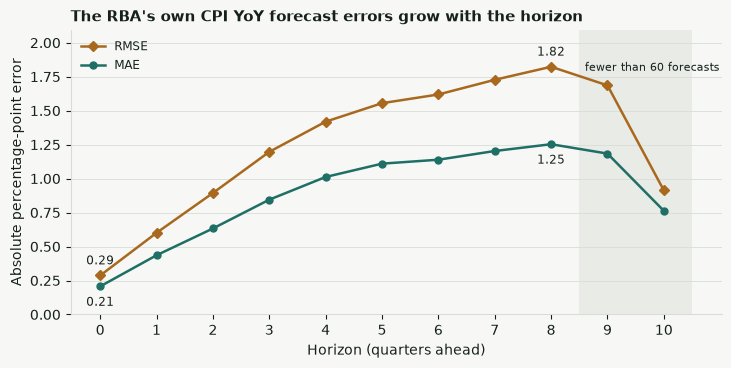

RBA forecast errors are summarised as percentage-point CPI YoY forecast errors. Use these horizon-level MAE/RMSE values as benchmark context only until model forecasts are generated on the same forecast-origin and horizon grid.

In [16]:
RBA_FORECAST_PATH = latest_dataset_path(ROOT / 'dataset' / 'rba' / 'rba_historical_cpi_forecasts_by_horizon_1995_2026.csv')

if RBA_FORECAST_PATH.exists():
    rba_forecasts = pd.read_csv(RBA_FORECAST_PATH)
    rba_forecasts['forecast_date'] = pd.to_datetime(rba_forecasts['forecast_date'], errors='coerce')
    rba_eval = rba_forecasts.loc[
        rba_forecasts['horizon_quarters'].ge(0)
        & rba_forecasts['rba_forecast_cpi_yoy'].notna()
        & rba_forecasts['rba_actual_cpi_yoy'].notna()
    ].copy()
    if 'rba_forecast_error_cpi_yoy' not in rba_eval or rba_eval['rba_forecast_error_cpi_yoy'].isna().all():
        rba_eval['rba_forecast_error_cpi_yoy'] = rba_eval['rba_actual_cpi_yoy'] - rba_eval['rba_forecast_cpi_yoy']
    rba_eval = rba_eval.loc[rba_eval['rba_forecast_error_cpi_yoy'].notna()].copy()
    rba_target_quarter = rba_eval['forecast_date'].dt.to_period('Q') + rba_eval['horizon_quarters'].astype(int)
    rba_eval = rba_eval.loc[rba_target_quarter <= EDA_END_QUARTER].copy()

    rba_horizon_error = (
        rba_eval.groupby('horizon_quarters')
        .agg(
            n_forecasts=('rba_forecast_error_cpi_yoy', 'size'),
            start_forecast_date=('forecast_date', 'min'),
            end_forecast_date=('forecast_date', 'max'),
            mean_error=('rba_forecast_error_cpi_yoy', 'mean'),
            mae=('rba_forecast_error_cpi_yoy', lambda s: s.abs().mean()),
            rmse=('rba_forecast_error_cpi_yoy', lambda s: np.sqrt(np.mean(np.square(s)))),
        )
        .reset_index()
    )
    rba_horizon_error['start_forecast_date'] = rba_horizon_error['start_forecast_date'].dt.strftime('%Y-%m-%d')
    rba_horizon_error['end_forecast_date'] = rba_horizon_error['end_forecast_date'].dt.strftime('%Y-%m-%d')
    with plt.rc_context(BOOK_STYLE):
        e = rba_horizon_error
        thin = e["n_forecasts"] < 60
        fig, ax = plt.subplots(figsize=(8.4, 3.7))
        ax.axvspan(e.loc[thin, "horizon_quarters"].min() - 0.5, e["horizon_quarters"].max() + 0.5, color=GRID, alpha=0.45, linewidth=0)
        ax.text(e.loc[thin, "horizon_quarters"].min() - 0.4, e["rmse"].max() * 1.02, "fewer than 60 forecasts", fontsize=8, va="top")
        ax.plot(e["horizon_quarters"], e["rmse"], color=HIGHLIGHT, marker="D", markersize=5, linewidth=1.8, label="RMSE")
        ax.plot(e["horizon_quarters"], e["mae"], color=ACCENT, marker="o", markersize=5, linewidth=1.8, label="MAE")
        for col, colour, dy in (("rmse", HIGHLIGHT, 8), ("mae", ACCENT, -14)):
            for h in (0, 8):
                row = e[e["horizon_quarters"] == h].iloc[0]
                ax.annotate(f"{row[col]:.2f}", (h, row[col]), xytext=(0, dy), textcoords="offset points", ha="center", fontsize=8.5)
        ax.set_ylim(0, e["rmse"].max() * 1.15)
        ax.set_xticks(e["horizon_quarters"])
        ax.set_xlabel("Horizon (quarters ahead)")
        ax.set_ylabel("Absolute percentage-point error")
        ax.set_title("The RBA's own CPI YoY forecast errors grow with the horizon", loc="left", fontsize=11, fontweight="bold")
        ax.legend(frameon=False, fontsize=8.5, loc="upper left")
        ax.grid(axis="x", visible=False)
        plt.show()


    display(Markdown('RBA forecast errors are summarised as percentage-point CPI YoY forecast errors. Use these horizon-level MAE/RMSE values as benchmark context only until model forecasts are generated on the same forecast-origin and horizon grid.'))
else:
    rba_horizon_error = pd.DataFrame()
    display(Markdown('RBA historical CPI forecast data is not present, so RBA forecast-error benchmarking remains blocked until the source file is retrieved.'))


**Interpretation.** The RBA's own published forecasts degrade sharply with horizon: mean
absolute error grows from 0.207 percentage points at horizon 0 (a same-quarter nowcast) to
1.253 points at horizon 8 (two years ahead), roughly a 6x increase, and RMSE follows the
same pattern (0.287 to 1.823). That's not a criticism of the RBA; multi-year-ahead inflation
is genuinely hard to forecast for anyone. What it does establish is exactly how high the bar
is at each horizon for this project's own models: beating a nowcast is a much easier bar to
clear than beating a 2-year-ahead forecast, which [§5 Evaluation](../05_evaluation) accounts
for by comparing at every horizon separately rather than only on an aggregate score.